## Этап 1. Проведите исследовательский анализ (EDA)
Загрузите датасет и визуализируйте часть данных. Изучите то, с чем предстоит работать  
Сформируйте видение:
- как вы будете решать задачу,
- какие подходы к обогащению/аугментации данных примените и почему,
- на какие метрики будете ориентироваться при обучении.
  
Объедините таблицы dish.csv и ingredients.csv.
В колонке ingredients таблицы dish.csv хранятся технические идентификаторы вида ingr_0000000122 — модель не извлечёт из них никакой информации о блюде.  Замените идентификаторы на реальные названия продуктов из ingredients.csv (колонка ingr), чтобы текстовая компонента модели получала осмысленный вход.  
Пример: "ingr_0000000122;ingr_0000000026" => "salmon, zucchini".  
Результаты: EDA и выводы о подходах к решению задачи.

In [1]:
!wget -O nutrition.zip "$(curl -s 'https://cloud-api.yandex.net/v1/disk/public/resources/download?public_key=https://disk.yandex.ru/d/kz9g5msVqtahiw' | python3 -c "import sys, json; print(json.load(sys.stdin)['href'])")"

--2026-06-09 09:06:42--  https://downloader.disk.yandex.ru/disk/021611b6f7216acb1bcba2b195488db16526c3f8b8fce1473efa3bd339991255/6a280fe2/o9NoyXwfnHa5z4QMLKCWPUyHnJN_k24GZvIDN7ccYLCE0DDpndIMEjKMqma53MgOFeHUx3Qc3WoqaCOKxoYJ4Q%3D%3D?uid=0&filename=nutrition.zip&disposition=attachment&hash=oH2ENYGwu/0OkTJSG5YdSldgVhjFH4lPzFN7cI%2BvwjEse0AvyDLUtow3hrnyNtNhq/J6bpmRyOJonT3VoXnDag%3D%3D%3A&limit=0&content_type=application%2Fzip&owner_uid=1996212855&fsize=1427106338&hid=73091fe62cc66450c26584c4a21cd3bd&media_type=compressed&tknv=v3&is_direct_zip_experiment=1
Resolving downloader.disk.yandex.ru (downloader.disk.yandex.ru)... 77.88.21.127, 2a02:6b8::2:127
Connecting to downloader.disk.yandex.ru (downloader.disk.yandex.ru)|77.88.21.127|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://s526klg.storage.yandex.net/rdisk/021611b6f7216acb1bcba2b195488db16526c3f8b8fce1473efa3bd339991255/6a280fe2/o9NoyXwfnHa5z4QMLKCWPUyHnJN_k24GZvIDN7ccYLCE0DDpndIMEjKMqma53MgOFeHUx3Q

In [2]:
!unzip nutrition.zip

Streaming output truncated to the last 5000 lines.
   creating: data/images/dish_1563295044/
   creating: data/images/dish_1563295292/
   creating: data/images/dish_1563295334/
   creating: data/images/dish_1563295360/
   creating: data/images/dish_1563295400/
   creating: data/images/dish_1563302315/
   creating: data/images/dish_1563302345/
   creating: data/images/dish_1563302391/
   creating: data/images/dish_1563302420/
   creating: data/images/dish_1563302447/
   creating: data/images/dish_1563303298/
   creating: data/images/dish_1563303350/
   creating: data/images/dish_1563303386/
   creating: data/images/dish_1563304261/
   creating: data/images/dish_1563304301/
   creating: data/images/dish_1563304333/
   creating: data/images/dish_1563304369/
   creating: data/images/dish_1563304881/
   creating: data/images/dish_1563304925/
   creating: data/images/dish_1563304958/
   creating: data/images/dish_1563305005/
   creating: data/images/dish_1563305047/
   creating: data/images/

In [3]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 20.6 MB/s eta 0:00:00


In [28]:
from scripts.utils import train
import torch


class Config:
    SEED = 42

    TEXT_MODEL_NAME = "bert-base-uncased"
    IMAGE_MODEL_NAME = "tf_efficientnet_b4"

    TEXT_MODEL_UNFREEZE = "encoder.layer.11|pooler"
    IMAGE_MODEL_UNFREEZE = "blocks.6|conv_head|bn2"


    BATCH_SIZE = 16
    TEXT_LR = 3e-5
    IMAGE_LR = 1e-4
    CLASSIFIER_LR = 1e-3
    EPOCHS = 30
    DROPOUT = 0.3
    HIDDEN_DIM = 256
    #NUM_CLASSES = 4

    DF_PATH = "./data/nutrition/data"
    TRAIN_DF_PATH = "./data/nutrition/data/train.csv"
    VAL_DF_PATH = "./data/nutrition/data/test.csv"
    #DF_PATH = "./data/"
    #TRAIN_DF_PATH = "./data/train.csv"
    #VAL_DF_PATH = "./data/test.csv"
    SAVE_PATH = "best_model.pth"


device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = Config()
print(device)

#train(cfg, device)

cpu


In [ ]:
import pandas as pd

DATASET_PATH = cfg.DF_PATH

dish_df = pd.read_csv(f'{DATASET_PATH}/dish.csv')
dish_df

,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train
...,...,...,...,...,...
3257,dish_1563295334,228.540009,96.0,ingr_0000000004;ingr_0000000008,train
3258,dish_1566329234,262.625214,457.0,ingr_0000000161;ingr_0000000189;ingr_000000000...,train
3259,dish_1562691737,485.676880,700.0,ingr_0000000543;ingr_0000000027;ingr_000000012...,train
3260,dish_1558458496,53.130001,77.0,ingr_0000000440,train


In [ ]:
ingr_df = pd.read_csv(f'{DATASET_PATH}/ingredients.csv')
ingr_df


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes
...,...,...
550,551,pizza sauce
551,552,pomegranate
552,553,nut cheese
553,554,soy sausage


In [ ]:
ingr_map = dict(zip(ingr_df['id'], ingr_df['ingr']))

# Функция для очистки 'ingr_0000000122' -> '122' и замены по словарю
def map_ingredients(ids_string):
    if pd.isna(ids_string) or not str(ids_string).strip():
        return ""

    ids_list = [i.strip() for i in str(ids_string).split(';')]

    clean_ids = [int(idx.replace('ingr_', '')) for idx in ids_list if 'ingr_' in idx]

    # Ищем названия в словаре
    names_list = [ingr_map.get(idx, idx) for idx in clean_ids]

    return ", ".join(names_list)


df = dish_df
df['ingredients'] = dish_df['ingredients'].apply(map_ingredients)




In [ ]:
df = df[['dish_id', 'ingredients', 'split','total_mass', 'total_calories']].copy()
df

,dish_id,ingredients,split,total_mass,total_calories
0,dish_1561662216,"soy sauce, garlic, white rice, parsley, onions...",test,193.0,300.794281
1,dish_1561662054,"pepper, white rice, mixed greens, garlic, soy ...",train,292.0,419.438782
2,dish_1562008979,"jalapenos, lemon juice, pork, wheat berry, cab...",test,290.0,382.936646
3,dish_1560455030,"cherry tomatoes, cucumbers, baby carrots",train,103.0,20.590000
4,dish_1558372433,deprecated,train,143.0,74.360001
...,...,...,...,...,...
3257,dish_1563295334,"bacon, scrambled eggs",train,96.0,228.540009
3258,dish_1566329234,"olive oil, vinegar, cauliflower, bok choy, mil...",train,457.0,262.625214
3259,dish_1562691737,"chia seeds, broccoli, egg whites, yam, chicken...",train,700.0,485.676880
3260,dish_1558458496,grapes,train,77.0,53.130001


In [ ]:
df_train=df[df['split'] == 'train'].drop(columns=['split'])
df_test=df[df['split'] == 'test'].drop(columns=['split'])

print(f'Рамзер train - {len(df_train)}\n{df_train}\nРазмер test - {len(df_test)}\n{df_test}')

Рамзер train - 2755
              dish_id                                        ingredients  \
1     dish_1561662054  pepper, white rice, mixed greens, garlic, soy ...   
3     dish_1560455030           cherry tomatoes, cucumbers, baby carrots   
4     dish_1558372433                                         deprecated   
5     dish_1565640549  tomatoes, cilantro, olive oil, mustard greens,...   
6     dish_1563207364  scrambled eggs, yam, grapes, egg whites, olive...   
...               ...                                                ...   
3257  dish_1563295334                              bacon, scrambled eggs   
3258  dish_1566329234  olive oil, vinegar, cauliflower, bok choy, mil...   
3259  dish_1562691737  chia seeds, broccoli, egg whites, yam, chicken...   
3260  dish_1558458496                                             grapes   
3261  dish_1568664931  tomatoes, vinegar, spinach (raw), mustard, oli...   

      total_mass  total_calories  
1          292.0      419.438782

In [ ]:
df_train.to_csv(cfg.TRAIN_DF_PATH, index=False)
df_test.to_csv(cfg.VAL_DF_PATH, index=False)


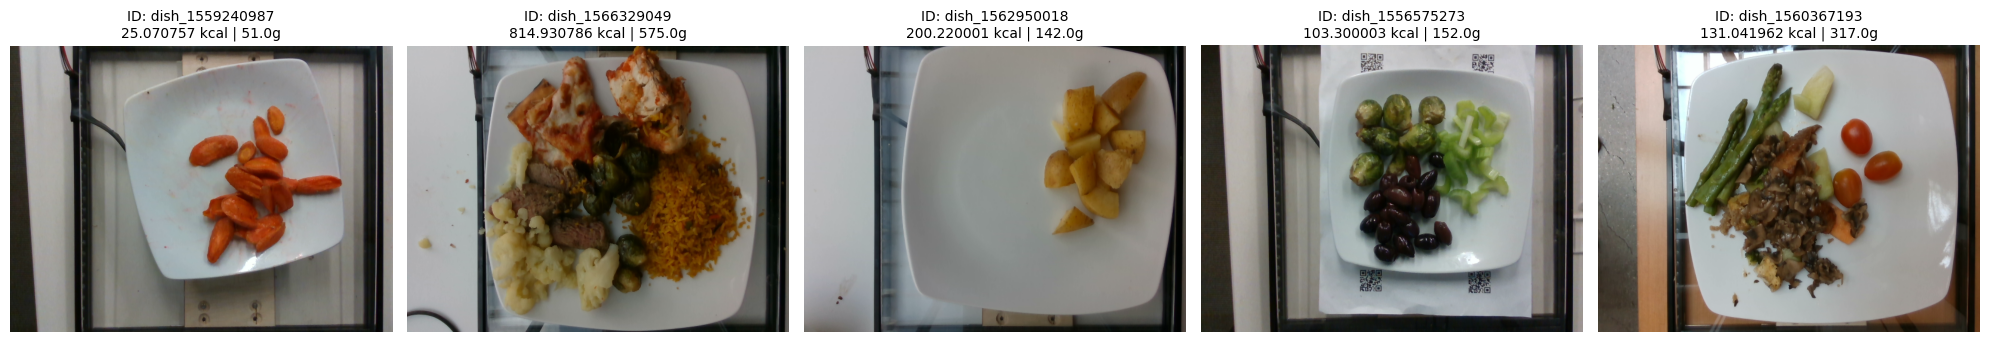

In [ ]:
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

sample_dishes = df_train.sample(5)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, (_, row) in enumerate(sample_dishes.iterrows()):
    dish_id = str(row["dish_id"])
    calories = row["total_calories"]
    mass = row["total_mass"]

    img_path = os.path.join(f'{DATASET_PATH}/images', dish_id, "rgb.png")
    img = Image.open(img_path)
    axes[i].imshow(img)
    axes[i].set_title(f"ID: {dish_id}\n{calories} kcal | {mass}g", fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Этап 2. Реализуйте пайплайн обучения

./scripts/dataset.py
./scripts/utils.py

## Этап 3. Обучение модели

In [ ]:
train(cfg, device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Разморожен слой: encoder.layer.11.attention.self.query.weight
Разморожен слой: encoder.layer.11.attention.self.query.bias
Разморожен слой: encoder.layer.11.attention.self.key.weight
Разморожен слой: encoder.layer.11.attention.self.key.bias
Разморожен слой: encoder.layer.11.attention.self.value.weight
Разморожен слой: encoder.layer.11.attention.self.value.bias
Разморожен слой: encoder.layer.11.attention.output.dense.weight
Разморожен слой: encoder.layer.11.attention.output.dense.bias
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.attention.output.LayerNorm.bias
Разморожен слой: encoder.layer.11.intermediate.dense.weight
Разморожен слой: encoder.layer.11.intermediate.dense.bias
Разморожен слой: encoder.layer.11.output.dense.weight
Разморожен слой: encoder.layer.11.output.dense.bias
Разморожен слой: encoder.layer.11.output.LayerNorm.weight
Разморожен слой: encoder.layer.11.output.LayerNorm.bias
Разморожен слой: pooler.dense.weight
Раз

## Этап 4. Валидация качества

In [29]:
from scripts.utils import MultimodalModel
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
cfg = Config()
model_val = MultimodalModel(cfg).to(device)
state_dict = torch.load("best_model.pth", map_location=device)
model_val.load_state_dict(state_dict)
model_val.eval()

MultimodalModel(
  (text_model): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, ele

### Финальная целевая метрика

In [6]:
from scripts.utils import validate
from scripts.dataset import MultimodalDataset, collate_fn, get_transforms
from functools import partial
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)

val_transforms = get_transforms(cfg, ds_type="val")
val_dataset = MultimodalDataset(cfg, val_transforms, ds_type="val")

val_loader = DataLoader(val_dataset,
                        batch_size=cfg.BATCH_SIZE,
                        shuffle=False,
                        collate_fn=partial(collate_fn,
                                            tokenizer=tokenizer))


val_mae = validate(model_val, val_loader, device)
print(f'Финальная целевая метрика - MAE: {val_mae}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Финальная целевая метрика - MAE: 49.63491285576153


### Топ-5 блюд, предсказанная калорийность которых значительно отличается от реальной.

In [31]:
from scripts.utils import validate
from scripts.dataset import MultimodalDataset, collate_fn, get_transforms
from functools import partial
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModel, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(cfg.TEXT_MODEL_NAME)

val_transforms = get_transforms(cfg, ds_type="val")
val_dataset = MultimodalDataset(cfg, val_transforms, ds_type="val")

val_loader = DataLoader(val_dataset,
                        batch_size=cfg.BATCH_SIZE,
                        shuffle=False,
                        collate_fn=partial(collate_fn,
                                            tokenizer=tokenizer))


all_predictions = []

with torch.no_grad():
        for batch in val_loader:
            inputs = {
                'input_ids': batch['input_ids'].to(device),
                'attention_mask': batch['attention_mask'].to(device),
                'image': batch['image'].to(device),
                'mass': batch['mass'].to(device)
            }
            labels = batch['label'].to(device)

            logits = model_val(**inputs)
            
            if logits.ndim > 1:
                logits = logits.squeeze(-1)
                
            all_predictions.extend(logits.cpu().numpy())
            



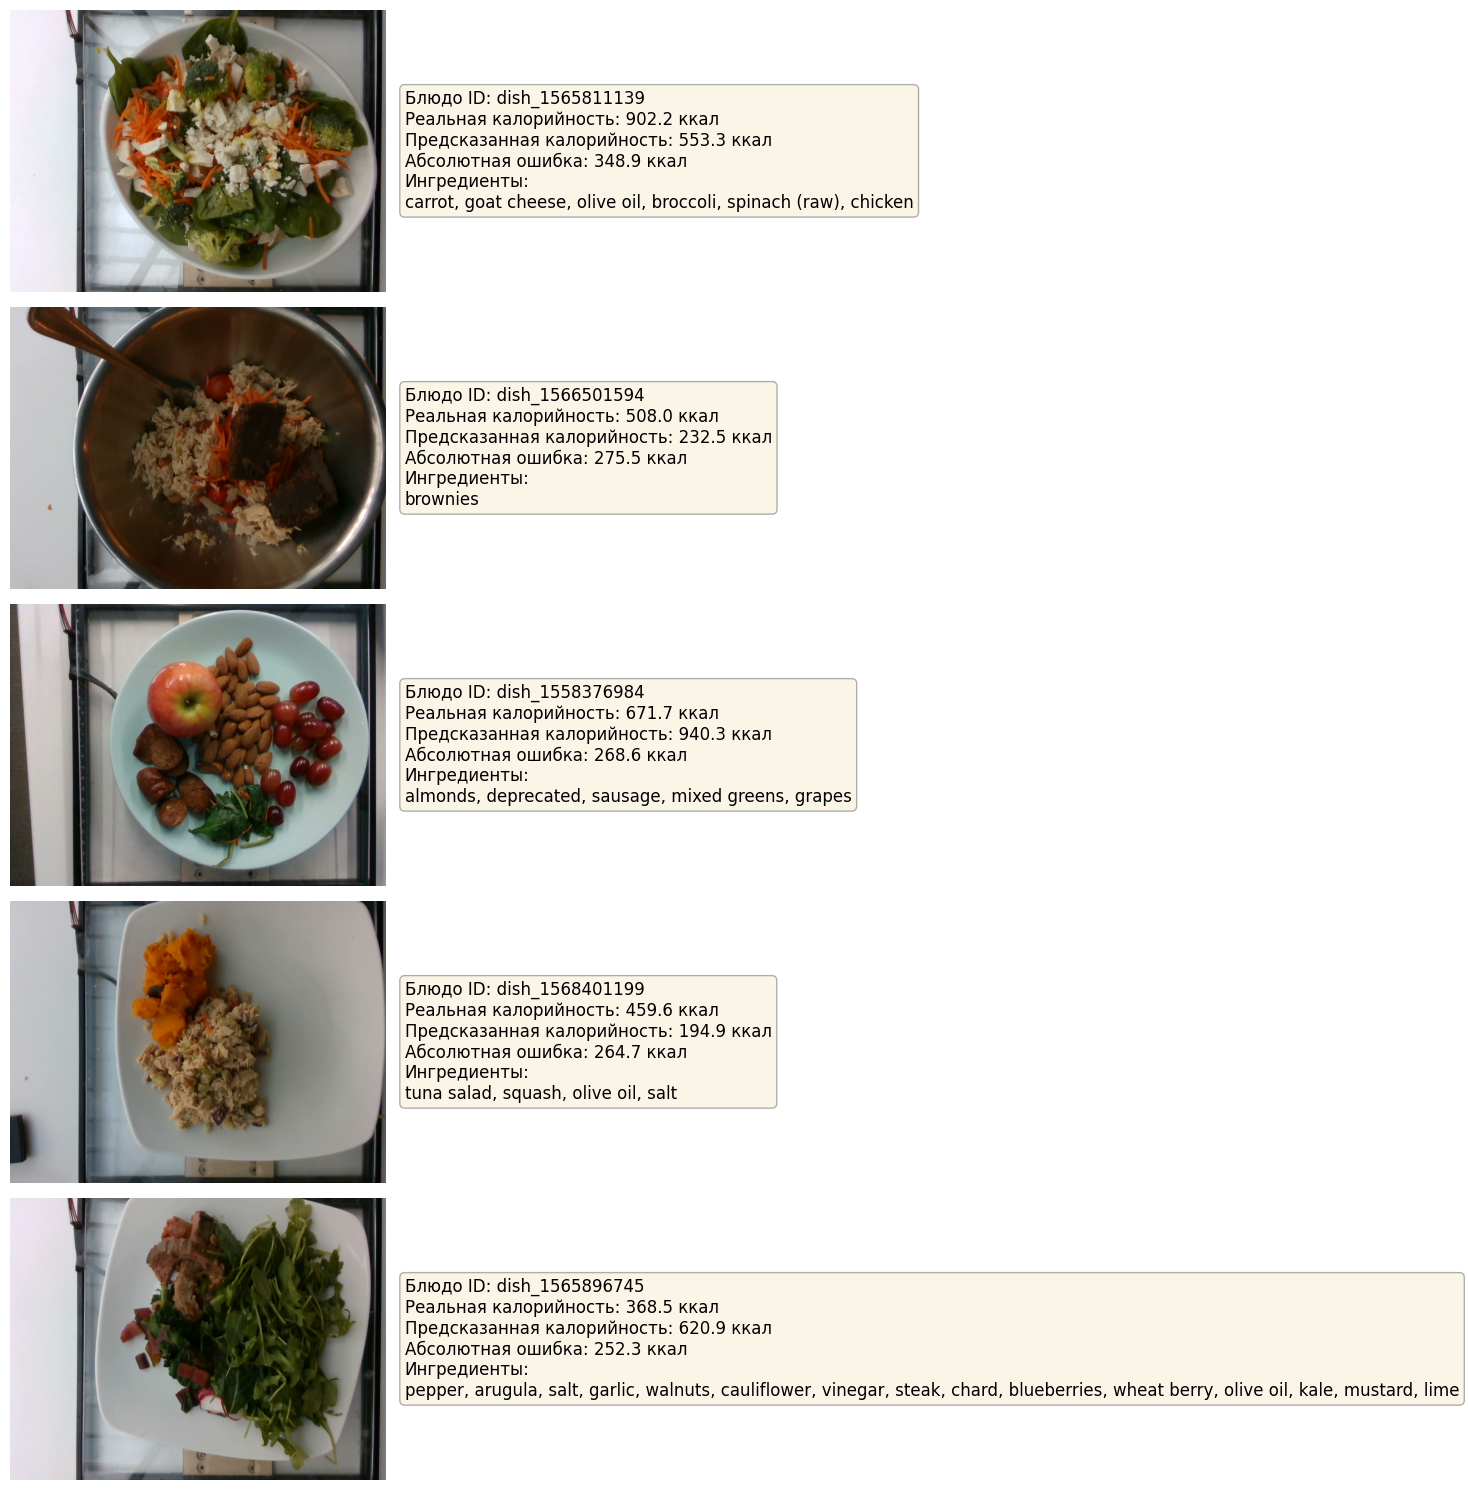

In [34]:
df_err = val_dataset.df.copy()
df_err['predicted_calories'] = all_predictions
df_err['abs_error'] = (df_err['total_calories'] - df_err['predicted_calories']).abs()

top_5_errors = df_err.sort_values(by='abs_error', ascending=False).head(5)

fig, axes = plt.subplots(5, 1, figsize=(12, 15))

for i, (_, row) in enumerate(top_5_errors.iterrows()):
    # Путь к исходному (не трансформированному) изображению
    img_path = os.path.join(cfg.DF_PATH, "images", str(row["dish_id"]), "rgb.png")
    
    try:
        image = Image.open(img_path)
    except FileNotFoundError:
        # Заглушка, если картинка не найдена
        image = Image.new('RGB', (224, 224), color='gray')
    
    # Отрисовка изображения
    axes[i].imshow(image)
    axes[i].axis('off')
    
    # Формирование текстового описания блюда
    title_text = (
        f"Блюдо ID: {row['dish_id']}\n"
        f"Реальная калорийность: {row['total_calories']:.1f} ккал\n"
        f"Предсказанная калорийность: {row['predicted_calories']:.1f} ккал\n"
        f"Абсолютная ошибка: {row['abs_error']:.1f} ккал\n"
        f"Ингредиенты:\n{row['ingredients']}"
    )
    
    # Вывод текста справа от картинки
    axes[i].text(
        1.05, 0.5, title_text, 
        transform=axes[i].transAxes, 
        fontsize=12, 
        verticalalignment='center',
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.3)
    )
    
plt.tight_layout()
plt.show()

### Проанализируйте эти примеры и опишите возможные причины ошибок, например, нетипичный размер порции, редкие или смешанные ингредиенты, некачественная фотография.
- dish_1565811139 - наличие калорийного оливкового масла, пропорцию которого модель не знает
- dish_1566501594 - наличие калорийного брауни, плохая освещенность
- dish_1558376984 - наличие калорийных сосисек и орехов + большая масса блюда
- dish_1568401199 - наличие калорийного оливкового масла + большая "открытая" площадь тарелки
- dish_1565896745 - большое количество ингридиентов, "объемный" вид блюда, плохая освещенность

In [35]:
top_5_errors

,dish_id,ingredients,total_mass,total_calories,predicted_calories,abs_error
141,dish_1565811139,"carrot, goat cheese, olive oil, broccoli, spin...",416.0,902.200012,553.295837,348.904175
170,dish_1566501594,brownies,109.0,508.048981,232.520737,275.528244
257,dish_1558376984,"almonds, deprecated, sausage, mixed greens, gr...",350.0,671.678040,940.320007,268.641967
204,dish_1568401199,"tuna salad, squash, olive oil, salt",343.0,459.643372,194.900024,264.743348
239,dish_1565896745,"pepper, arugula, salt, garlic, walnuts, caulif...",244.0,368.540344,620.859802,252.319458
